To answer some questions about clips and their presentation 

In [15]:
import datajoint as dj

import sys
sys.path.append("/workspaces/microns_phase3_nda/")
from microns_phase3 import nda, utils
from collections import Counter

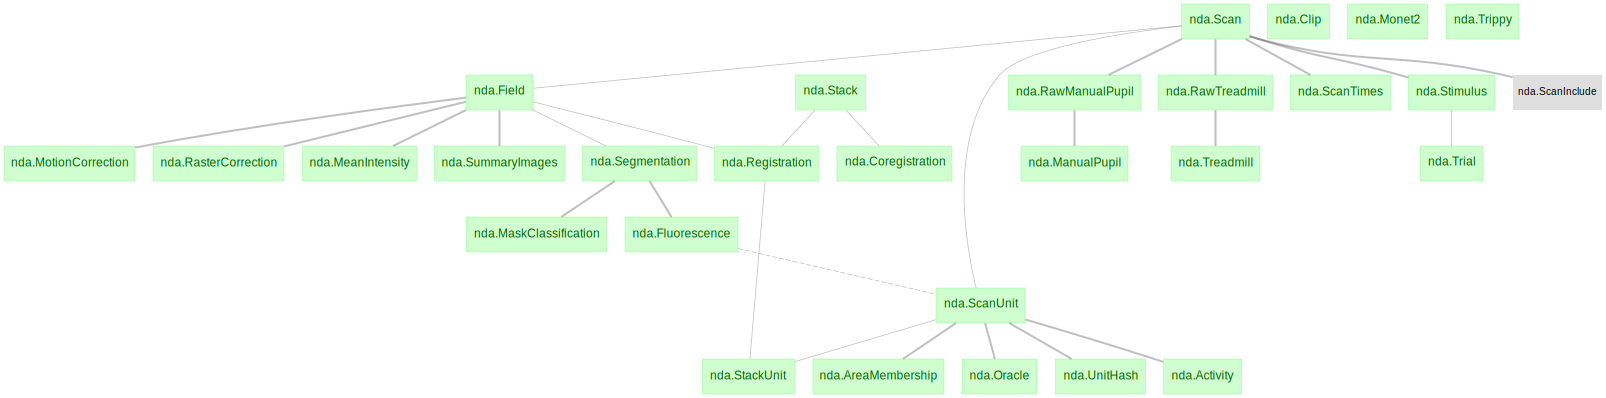

In [2]:
dj.ERD(nda)

In [31]:
nda.Clip()

condition_hash 120-bit hash (The first 20 chars of MD5 in base64),movie_name full clip source,duration duration of clip (seconds),clip clip used for stimulus (T x H x W),"short_movie_name clip type (cinematic, sports1m, rendered)",fps original framerate of clip
++P2FvCjFYUoW5tupHjw,2012 May 28 ICUP 7th Annual Stan Crane Memorial XC Mountain Bike Race,10.000,=BLOB=,sports1m,30.0
+15m1aMsMNJa3sNnsquh,Powaqqatsi: Life in Transformation (1988),10.000,=BLOB=,Cinematic,30.0
+183tDR6amwLF5IJXvWR,Mad Max: Fury Road (2015),10.000,=BLOB=,Cinematic,30.0
+2PGTTYOs/nE3q8zaYUA,2012 May 28 ICUP 7th Annual Stan Crane Memorial XC Mountain Bike Race,10.000,=BLOB=,sports1m,30.0
+2QLCop5iv/3ozCv1IzN,mountainlake_001-1-0-70-0_184.73.123.94,10.000,=BLOB=,Rendered,30.0
+362QNoEO1SY063VG99r,kowloon_119-1-8-70-0_54.89.40.102,10.000,=BLOB=,Rendered,30.0
+3g/lYsSjc3Di/C6RGoU,2011 Frozen Hog Mountain Bike Race,10.000,=BLOB=,sports1m,30.0
+4Ga/yTa4CkgZaN5FK/N,Naqoyqatsi: Life as War (2002),10.000,=BLOB=,Cinematic,30.0
+58o3lq61cXuA5ByO/+c,2012 HAFJELL NORWAY DOWNHILL MTB WORLD CUP RECAP YouTube,10.000,=BLOB=,sports1m,30.0
+5KOuf8AHbZQV2+gVin2,Koyaanisqatsi: Life Out of Balance (1982),10.000,=BLOB=,Cinematic,30.0


In [32]:
## Were all clips in nda.Clips shown?
shown_hashes = set(nda.Trial().fetch("condition_hash"))
cine_sports_clip_hashes = set((nda.Clip() & [{"short_movie_name": name} for name in ["sports1m", "Cinematic"]]).fetch("condition_hash"))
print(f"sport, cine Clips in nda.Clip not shown {cine_sports_clip_hashes-shown_hashes}, {len(cine_sports_clip_hashes)=}, {len(shown_hashes)=}")


sport, cine Clips in nda.Clip not shown set(), len(cine_sports_clip_hashes)=1888, len(shown_hashes)=3228


In [40]:
## Which clips were oracle clips? 
oracle_sports_cine_hashes = []
for scan_key in nda.Scan().proj().fetch():
    scan_condition_hashes = (nda.Trial() & scan_key).fetch("condition_hash")
    scan_cine_sports_hashes =list(filter(lambda hash_: hash_ in cine_sports_clip_hashes,scan_condition_hashes) )
    
    hash_counts = Counter(scan_cine_sports_hashes).most_common()

    # they presented 2 oracles per scan for each natural movie category so 4 for sports and cine
    assert hash_counts[4][1] < 10
    scan_oracle_clips = [tup[0] for tup in hash_counts[:4]]
    oracle_sports_cine_hashes.extend(scan_oracle_clips)


    print(f"{scan_key=}, {scan_oracle_clips=}, {hash_counts[:5]=}")

print(set(oracle_sports_cine_hashes))

scan_key=(4, 7), scan_oracle_clips=['5zQTb77qI+ig8rigx1XU', 'ecUQJtcERZJGdqza1k7h', '7UETOWO5Z8aWuHDBJ2GG', 'Oup5uAZxF2G7zEJkT+ui'], hash_counts[:5]=[('5zQTb77qI+ig8rigx1XU', 10), ('ecUQJtcERZJGdqza1k7h', 10), ('7UETOWO5Z8aWuHDBJ2GG', 10), ('Oup5uAZxF2G7zEJkT+ui', 10), ('mG4xsIyTTnaRWKW82yeD', 2)]
scan_key=(4, 9), scan_oracle_clips=['ecUQJtcERZJGdqza1k7h', '7UETOWO5Z8aWuHDBJ2GG', '5zQTb77qI+ig8rigx1XU', 'Oup5uAZxF2G7zEJkT+ui'], hash_counts[:5]=[('ecUQJtcERZJGdqza1k7h', 10), ('7UETOWO5Z8aWuHDBJ2GG', 10), ('5zQTb77qI+ig8rigx1XU', 10), ('Oup5uAZxF2G7zEJkT+ui', 10), ('ihsP/Q14/eSpxdQLR3F4', 2)]
scan_key=(4, 10), scan_oracle_clips=['Oup5uAZxF2G7zEJkT+ui', 'ecUQJtcERZJGdqza1k7h', '5zQTb77qI+ig8rigx1XU', '7UETOWO5Z8aWuHDBJ2GG'], hash_counts[:5]=[('Oup5uAZxF2G7zEJkT+ui', 10), ('ecUQJtcERZJGdqza1k7h', 10), ('5zQTb77qI+ig8rigx1XU', 10), ('7UETOWO5Z8aWuHDBJ2GG', 10), ('Mg5bLgoNvze3EPLB9rbZ', 2)]
scan_key=(5, 3), scan_oracle_clips=['5zQTb77qI+ig8rigx1XU', 'ecUQJtcERZJGdqza1k7h', 'Oup5uAZxF2G7zEJkT

Okay so these seem to be the 4 oracle clips in the microns sports and cine sessions {'7UETOWO5Z8aWuHDBJ2GG', '5zQTb77qI+ig8rigx1XU', 'ecUQJtcERZJGdqza1k7h', 'Oup5uAZxF2G7zEJkT+ui'}